## Read in Datasets

In [32]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statistics
from scipy import stats
import math

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.weightstats import DescrStatsW
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

In [33]:
# see all columns
pd.set_option('display.max_columns', None)

In [94]:
# READ IN CEX DATASETS
# ignore mixed types column warnings as they are irrelevant for our analysis
Q2_2016 = pd.read_csv("PUMD_datasets/2016_pumd/intrvw16/fmli162.csv", low_memory=False)
Q3_2016 = pd.read_csv("PUMD_datasets/2016_pumd/intrvw16/fmli163.csv")
Q4_2016 = pd.read_csv("PUMD_datasets/2016_pumd/intrvw16/fmli164.csv", low_memory=False)
Q1_2017 = pd.read_csv("PUMD_datasets/2016_pumd/intrvw16/fmli171.csv", low_memory=False)

Q2_2017 = pd.read_csv("PUMD_datasets/2017_pumd/intrvw17/fmli172.csv")
Q3_2017 = pd.read_csv("PUMD_datasets/2017_pumd/intrvw17/fmli173.csv")
Q4_2017 = pd.read_csv("PUMD_datasets/2017_pumd/intrvw17/fmli174.csv")
Q1_2018 = pd.read_csv("PUMD_datasets/2017_pumd/intrvw17/fmli181.csv")

Q2_2018 = pd.read_csv("PUMD_datasets/2018_pumd/intrvw18/fmli182.csv")
Q3_2018 = pd.read_csv("PUMD_datasets/2018_pumd/intrvw18/fmli183.csv")
Q4_2018 = pd.read_csv("PUMD_datasets/2018_pumd/intrvw18/fmli184.csv")
Q1_2019 = pd.read_csv("PUMD_datasets/2018_pumd/intrvw18/fmli191.csv")

Q2_2019 = pd.read_csv("PUMD_datasets/2019_pumd/intrvw19/fmli192.csv")
Q3_2019 = pd.read_csv("PUMD_datasets/2019_pumd/intrvw19/fmli193.csv")
Q4_2019 = pd.read_csv("PUMD_datasets/2019_pumd/intrvw19/fmli194.csv")
Q1_2020 = pd.read_csv("PUMD_datasets/2019_pumd/intrvw19/fmli201.csv")

Q2_2020 = pd.read_csv("PUMD_datasets/2020_pumd/intrvw20/fmli202.csv")
Q3_2020 = pd.read_csv("PUMD_datasets/2020_pumd/intrvw20/fmli203.csv")
Q4_2020 = pd.read_csv("PUMD_datasets/2020_pumd/intrvw20/fmli204.csv")
Q1_2021 = pd.read_csv("PUMD_datasets/2020_pumd/intrvw20/fmli211.csv")

Q2_2021 = pd.read_csv("PUMD_datasets/2021_pumd/intrvw21/fmli212.csv")
Q3_2021 = pd.read_csv("PUMD_datasets/2021_pumd/intrvw21/fmli213.csv", low_memory=False)
Q4_2021 = pd.read_csv("PUMD_datasets/2021_pumd/intrvw21/fmli214.csv")
Q1_2022 = pd.read_csv("PUMD_datasets/2021_pumd/intrvw21/fmli221.csv")

Q2_2022 = pd.read_csv("PUMD_datasets/2022_pumd/intrvw22/fmli222.csv")
Q3_2022 = pd.read_csv("PUMD_datasets/2022_pumd/intrvw22/fmli223.csv")
Q4_2022 = pd.read_csv("PUMD_datasets/2022_pumd/intrvw22/fmli224.csv")
Q1_2023 = pd.read_csv("PUMD_datasets/2022_pumd/intrvw22/fmli231.csv")

Q2_2023 = pd.read_csv("PUMD_datasets/2023_pumd/intrvw23/fmli232.csv")
Q3_2023 = pd.read_csv("PUMD_datasets/2023_pumd/intrvw23/fmli233.csv") 
Q4_2023 = pd.read_csv("PUMD_datasets/2023_pumd/intrvw23/fmli234.csv")
Q1_2024 = pd.read_csv("PUMD_datasets/2023_pumd/intrvw23/fmli241.csv")

In [35]:
# combine CEX data by year
# reminder: main food variables refer to the prior quarter. as such, full calendar year is Q4 of prev yr and  Q1, Q2, and Q3 of current year
df_2016 = pd.concat([Q2_2016, Q3_2016, Q4_2016, Q1_2017], keys=[1,2,3,4])
df_2017 = pd.concat([Q2_2017, Q3_2017, Q4_2017, Q1_2018], keys=[5,6,7,8])
df_2018 = pd.concat([Q2_2018, Q3_2018, Q4_2018, Q1_2019], keys=[9,10,11,12])
df_2019 = pd.concat([Q2_2019, Q3_2019, Q4_2019, Q1_2020], keys=[13,14,15,16])
df_2020 = pd.concat([Q2_2020, Q3_2020, Q4_2020, Q1_2021], keys=[17,18,19,20])
df_2021 = pd.concat([Q2_2021, Q3_2021, Q4_2021, Q1_2022], keys=[21,22,23,24])
df_2022 = pd.concat([Q2_2022, Q3_2022, Q4_2022, Q1_2023], keys=[25,26,27,28])
df_2023 = pd.concat([Q2_2023, Q3_2023, Q4_2023, Q1_2024], keys=[29,30,31,32])

# making keys/index col into "quarter"
for df in [df_2016, df_2017, df_2018, df_2019, df_2020, df_2021, df_2022, df_2023]:
    df.reset_index(inplace=True)
    df.rename(columns={"level_0": "quarter"}, inplace=True)

# create year column
df_2016['year'] = 2016
df_2017['year'] = 2017
df_2018['year'] = 2018
df_2019['year'] = 2019
df_2020['year'] = 2020
df_2021['year'] = 2021
df_2022['year'] = 2022
df_2023['year'] = 2023

C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\190790440.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.reset_index(inplace=True)
C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\190790440.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.reset_index(inplace=True)
C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\190790440.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once

In [36]:
# read in federal poverty level (FPL) spreadsheets
fpl_16 = pd.read_csv('fpl-2016to2025/fpl-2016to2025 - fpl_2016.csv')[['numppl', '0', '50', '100', '150', '200']]
fpl_17 = pd.read_csv('fpl-2016to2025/fpl-2016to2025 - fpl_2017.csv')[['numppl', '0', '50', '100', '150', '200']]
fpl_18 = pd.read_csv('fpl-2016to2025/fpl-2016to2025 - fpl_2018.csv')[['numppl', '0', '50', '100', '150', '200']]
fpl_19 = pd.read_csv('fpl-2016to2025/fpl-2016to2025 - fpl_2019.csv')[['numppl', '0', '50', '100', '150', '200']]
fpl_20 = pd.read_csv('fpl-2016to2025/fpl-2016to2025 - fpl_2020.csv')[['numppl', '0', '50', '100', '150', '200']]
fpl_21 = pd.read_csv('fpl-2016to2025/fpl-2016to2025 - fpl_2021.csv')[['numppl', '0', '50', '100', '150', '200']]
fpl_22 = pd.read_csv('fpl-2016to2025/fpl-2016to2025 - fpl_2022.csv')[['numppl', '0', '50', '100', '150', '200']]
fpl_23 = pd.read_csv('fpl-2016to2025/fpl-2016to2025 - fpl_2023.csv')[['numppl', '0', '50', '100', '150', '200']]

# change FPL dfs to different % levels
for df in [fpl_16, fpl_17, fpl_18, fpl_19, fpl_20, fpl_21, fpl_22, fpl_23]:
    df['25'] = round(df['100'] * .25).astype('int')
    df['75'] = round(df['100'] * .75).astype('int')
    df['125'] = round(df['100'] * 1.25).astype('int')
    df['175'] = round(df['100'] * 1.75).astype('int')
    df['225'] = round(df['100'] * 2.25).astype('int')

# subset to relevant columns only
fpl_16 = fpl_16.loc[:, ['numppl', '0', '25', '50', '75', '100', '125', '150', '175', '200', '225']]
fpl_17 = fpl_17.loc[:, ['numppl', '0', '25', '50', '75', '100', '125', '150', '175', '200', '225']]
fpl_18 = fpl_18.loc[:, ['numppl', '0', '25', '50', '75', '100', '125', '150', '175', '200', '225']]
fpl_19 = fpl_19.loc[:, ['numppl', '0', '25', '50', '75', '100', '125', '150', '175', '200', '225']]
fpl_20 = fpl_20.loc[:, ['numppl', '0', '25', '50', '75', '100', '125', '150', '175', '200', '225']]
fpl_21 = fpl_21.loc[:, ['numppl', '0', '25', '50', '75', '100', '125', '150', '175', '200', '225']]
fpl_22 = fpl_22.loc[:, ['numppl', '0', '25', '50', '75', '100', '125', '150', '175', '200', '225']]
fpl_23 = fpl_23.loc[:, ['numppl', '0', '25', '50', '75', '100', '125', '150', '175', '200', '225']]

### Dummy FPL Columns

In [37]:
# creating multiple dummy columns for all poverty ranges based on income levels
# ex: "below50" column will be: 1, 0, 0, 1, 0, 0, 0, 0, 1, 0..

# Define the poverty level ranges with lower and upper income bounds
poverty_ranges = [
    ("0-25%", "0", "25"),
    ("25-50%", "25", "50"),
    ("50-75%", "50", "75"),
    ("75-100%", "75", "100"),
    ("100-125%", "100", "125"),
    ("125-150%", "125", "150"),
    ("150-175%", "150", "175"),
    ("175-200%", "175", "200"),
    ("200-225%", "200", "225")
]

# lists and dictionary for looping through FPL dfs
dffpl_list = [fpl_16, fpl_17, fpl_18, fpl_19, fpl_20, fpl_21, fpl_22, fpl_23]
year_list = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
fpl_dict = dict(zip(year_list, dffpl_list))

# making FPL dummy cols accordingly to each df and its respective year
def fpl_dummy_col (df, year):
    for label, lower_col, upper_col in poverty_ranges:
        df[label] = 0  # Initialize the column
        for index, row in fpl_dict[year].iterrows():
            numppl = row['numppl']
            if numppl > 0:
                lower_bound = row[lower_col]
                upper_bound = row[upper_col]
                # Update the column based on the conditions
                df[label] |= (
                    (df['FAM_SIZE'] == numppl) &
                    (df['FINCBTXM'] >= lower_bound) &
                    (df['FINCBTXM'] <= upper_bound)
                ).astype(int)

fpl_dummy_col(df_2016, 2016)
fpl_dummy_col(df_2017, 2017)
fpl_dummy_col(df_2018, 2018)
fpl_dummy_col(df_2019, 2019)
fpl_dummy_col(df_2020, 2020)
fpl_dummy_col(df_2021, 2021)
fpl_dummy_col(df_2022, 2022)
fpl_dummy_col(df_2023, 2023)

C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\2261800813.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[label] = 0  # Initialize the column
C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\2261800813.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[label] = 0  # Initialize the column
C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\2261800813.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

### Weights Data

In [38]:
# read in STATE WEIGHTS
df_cawgt23 = pd.read_csv("PUMD_datasets/state_weights/cex23_xlsx/Interview/cawgt.csv") 
df_cawgt22 = pd.read_csv("PUMD_datasets/state_weights/cex22_xlsx/Interview/cawgt22.csv")
df_cawgt21 = pd.read_csv("PUMD_datasets/state_weights/cex21_xlsx/Interview/cawgt21.csv")
df_cawgt20 = pd.read_excel("PUMD_datasets/state_weights/cex20_xlsx/Interview/cawgt20.xlsx") 
df_cawgt19 = pd.read_excel("PUMD_datasets/state_weights/cex19_xlsx/Interview/cawgt19.xlsx")
df_cawgt18 = pd.read_excel("PUMD_datasets/state_weights/cex18_xlsx/Interview/cawgt18.xlsx") 
df_cawgt17 = pd.read_excel("PUMD_datasets/state_weights/cex17_xlsx/Interview/cawgt17.xlsx")
df_cawgt16 = pd.read_excel("PUMD_datasets/state_weights/cex16_xlsx/Interview/cawgt16.xlsx")

# standardize column names
df_cawgt23.rename(columns={"PSU": "psu", "STATE": "state", 'st_wgt': "state_weight"}, inplace=True)
df_cawgt22.rename(columns={"PSU": "psu", "STATE": "state", 'st_wgt': "state_weight"}, inplace=True)
df_cawgt21.rename(columns={"newid": "NEWID", "WTREP45": "state_weight"}, inplace=True)
df_cawgt20.rename(columns={"newid": "NEWID", "cawgt": "state_weight"}, inplace=True)
df_cawgt19.rename(columns={"newid": "NEWID", "cawgt": "state_weight"}, inplace=True)
df_cawgt18.rename(columns={"newid": "NEWID", "cawgt": "state_weight"}, inplace=True)
df_cawgt17.rename(columns={"newid": "NEWID", "cawgt": "state_weight"}, inplace=True)
df_cawgt16.rename(columns={"newid": "NEWID", "cawgt": "state_weight"}, inplace=True)

# LEFT MERGE (keep all households, add state weight where applicable, fill in 0 for non-CA households)
# must merge each year as there are duplicate newid's across years
df_full23 = pd.merge(df_2023, df_cawgt23, on='NEWID', how='left')
df_full22 = pd.merge(df_2022, df_cawgt22, on='NEWID', how='left')
df_full21 = pd.merge(df_2021, df_cawgt21, on='NEWID', how='left')
df_full20 = pd.merge(df_2020, df_cawgt20, on='NEWID', how='left')
df_full19 = pd.merge(df_2019, df_cawgt19, on='NEWID', how='left')
df_full18 = pd.merge(df_2018, df_cawgt18, on='NEWID', how='left')
df_full17 = pd.merge(df_2017, df_cawgt17, on='NEWID', how='left')
df_full16 = pd.merge(df_2016, df_cawgt16, on='NEWID', how='left')

df_full = pd.concat([df_full16, df_full17, df_full18, df_full19, 
                     df_full20, df_full21, df_full22, df_full23], 
                     keys=[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])


# households without a state weight are not in that state
# non-CA houses fill with 0
df_full.fillna({'state_weight': 0}, inplace=True)
df_full[['FINLWT21', 'state_weight']].describe()

,FINLWT21,state_weight
count,172172.000000,172172.000000
mean,24560.776556,2654.021918
std,10030.120765,8329.285792
min,940.429000,0.000000
25%,18490.661000,0.000000
50%,23667.573000,0.000000
75%,29443.309750,0.000000
max,159391.586000,108871.071540


In [39]:
# changing year level weights to quarter level
df_full[['FINLWT21', 'state_weight']] = df_full[['FINLWT21', 'state_weight']]/4

df_full['FINLWT21'].isna().sum()

np.int64(0)

### Cleaning df_full

In [40]:
df_full.shape

(172172, 864)

In [41]:
# subset and rename relevant cols
cols = {"NEWID": "newid", "FINCBTXM": "fam_inc", "FINLWT21": "nation_weight",
        "FOODCQ": "food_cq", "FOODPQ": "foodpq", "FAM_SIZE": "fam_size",
        "JFS_AMTM": "ebt_yearly_impt", "FS_AMTXM": "ebt_monthly",
        "JFS_AMT": "ebt_yearly", "FS_MTHI": "ebt_months_enrolled"}
df_full.rename(columns = cols, inplace=True)
df_full = df_full[["year", "quarter", "newid", "fam_inc", "nation_weight", "state_weight",
                   "food_cq", "foodpq", "fam_size", 
                   "ebt_yearly_impt", "ebt_monthly", "ebt_yearly", "ebt_months_enrolled", 
                         "0-25%", "25-50%", "50-75%","75-100%", "100-125%", "125-150%", "150-175%", "175-200%", "200-225%"]]


In [42]:
# misc cleaning

# older datasets have '.' (periods). replace with NaN and convert to numeric
df_full.replace({'ebt_monthly': '.'}, np.nan, inplace=True)
df_full.replace({'ebt_months_enrolled': '.'}, np.nan, inplace=True)
df_full['ebt_monthly'] = pd.to_numeric(df_full['ebt_monthly'])
df_full['ebt_months_enrolled'] = pd.to_numeric(df_full['ebt_months_enrolled'])

# data cleaning
# missing values under ebt_monthly, ebt_yearly, ebt_months_enrolled, welfare_money
# households that do not receive EBT or welfare should be 0 instead of NA
df_full.fillna(0, inplace=True)

# ensure year col is int
df_full['year'] = df_full.loc[:,'year'].astype('int')

In [43]:
# renaming columns and creating new columns

# Renaming columns
df_full['TotIncome'] = df_full['fam_inc']
df_full['TotFoodQuarter'] = df_full['foodpq']
df_full['FamSize'] = df_full['fam_size']
df_full['AnnualSnap'] = df_full['ebt_yearly']
df_full['LastSnap'] = df_full['ebt_monthly']
df_full['MonthsofSnap'] = df_full['ebt_months_enrolled']
df_full['IncomePerPerson'] = df_full['fam_inc'] / df_full['fam_size']
df_full['MonthlyIncomePerPerson'] = df_full['IncomePerPerson']/12

# Create new columns
df_full['MonthlySnapIssuance'] = df_full['ebt_yearly'] / df_full['ebt_months_enrolled'] #NaNs from dividing by zero
df_full['MonthlySnapIssuance'].fillna(0, inplace=True)
df_full['MonthlyEBTPerPerson'] = df_full['ebt_monthly'] / df_full['fam_size']

# Perform food spending calculations
df_full['QuarterFoodSpendPerPerson'] = df_full['TotFoodQuarter'] / df_full['FamSize']
df_full['MonthlyFoodSpendPerPerson'] = df_full['QuarterFoodSpendPerPerson'] / 3
df_full['MonthlyFoodSpendPerPersonNoSnap'] = df_full['MonthlyFoodSpendPerPerson'] - df_full['MonthlyEBTPerPerson']
df_full['food_to_inc'] =  df_full['MonthlyFoodSpendPerPerson'] / (df_full['MonthlyIncomePerPerson']) *100

df_full['food_to_inc_nosnap'] =  df_full['MonthlyFoodSpendPerPersonNoSnap'] / (df_full['MonthlyIncomePerPerson']) *100

C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\1342339571.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_full['MonthlySnapIssuance'].fillna(0, inplace=True)


In [44]:
# dummy ebt
df_full['EBT_dummy'] = np.where(df_full['ebt_yearly']>0, True, False)

In [45]:
# creating log transformation columns
# ln transform the following variables for better regression interpretation (as __% inc, __ inc by __%)
df_full['MonthlyIncomePerPerson_ln'] = np.log(df_full['MonthlyIncomePerPerson'])
df_full['MonthlyEBTPerPerson_ln'] = np.log(df_full['MonthlyEBTPerPerson'])
# df_full['MonthlyFoodSpendPerPerson_ln'] = np.log(df_full['MonthlyFoodSpendPerPerson'] + 1)
df_full['MonthlyFoodSpendPerPersonNoSnap_ln'] = np.log10(df_full['MonthlyFoodSpendPerPersonNoSnap']) 

# log transform the following variables for better graphing (10, 100, 1000, 10000, ...)
df_full['MonthlyEBTPerPerson_log'] = np.log10(df_full['MonthlyEBTPerPerson']+1)
df_full['MonthlyIncomePerPerson_log'] = np.log10(df_full['MonthlyIncomePerPerson'])
df_full['MonthlyFoodSpendPerPersonNoSnap_log'] = np.log10(df_full['MonthlyFoodSpendPerPersonNoSnap']) 

c:\Users\ariel\programming\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ariel\programming\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ariel\programming\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ariel\programming\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ariel\programming\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ariel\programming\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero en

In [46]:
# data cleaning

# Filter out rows with invalid values
df_full = df_full[df_full['MonthlyFoodSpendPerPerson'] > 1]
df_full = df_full[df_full['MonthlyFoodSpendPerPersonNoSnap'] > 0]

# Exclude outliers

# Calculate 'outlier' as (TotIncome / 4) - TotFoodQuarter
df_full['outlier'] = (df_full['TotIncome'] / 4) - df_full['TotFoodQuarter']

# Create 'outlier2' column: 1 if 'outlier' >= 0, otherwise 0
# basically, if income > food expenditure, set to 1, otherwise 0
df_full['outlier2'] = np.where(df_full['outlier'] >= 0, 1, 0)

# Only incldue rows where 'outlier2' 
# Only include rows/households that report higher income than food expenditure
df_full = df_full[df_full['outlier2'] != 0]

df_full.head(2)

year  quarter    newid  fam_inc  nation_weight  state_weight  food_cq  \
2016 0  2016        1  3184644  42001.0     4143.13475   3985.501806      0.0   
     1  2016        1  3184664  95169.4     2548.67675      0.000000      0.0   

        foodpq  fam_size  ebt_yearly_impt  ebt_monthly  ebt_yearly  \
2016 0  1105.0         1                0          0.0           0   
     1  1560.0         3                0          0.0           0   

        ebt_months_enrolled  0-25%  25-50%  50-75%  75-100%  100-125%  \
2016 0                  0.0      0       0       0        0         0   
     1                  0.0      0       0       0        0         0   

        125-150%  150-175%  175-200%  200-225%  TotIncome  TotFoodQuarter  \
2016 0         0         0         0         0    42001.0          1105.0   
     1         0         0         0         0    95169.4          1560.0   

        FamSize  AnnualSnap  LastSnap  MonthsofSnap  IncomePerPerson  \
2016 0        1           0       0.0           0.0     42001.000000   
     1        3           0       0.0           0.0     31723.133333   

        MonthlyIncomePerPerson  MonthlySnapIssuance  MonthlyEBTPerPerson  \
2016 0             3500.083333                  0.0                  0.0   
     1             2643.594444                  0.0                  0.0   

        QuarterFoodSpendPerPerson  MonthlyFoodSpendPerPerson  \
2016 0                     1105.0                 368.333333   
     1                      520.0                 173.333333   

        MonthlyFoodSpendPerPersonNoSnap  food_to_inc  food_to_inc_nosnap  \
2016 0                       368.333333    10.523559           10.523559   
     1                       173.333333     6.556729            6.556729   

        EBT_dummy  MonthlyIncomePerPerson_ln  MonthlyEBTPerPerson_ln  \
2016 0      False                   8.160542                    -inf   
     1      False                   7.879895                    -inf   

        MonthlyFoodSpendPerPersonNoSnap_ln  MonthlyEBTPerPerson_log  \
2016 0                            2.566241                      0.0   
     1                            2.238882                      0.0   

        MonthlyIncomePerPerson_log  MonthlyFoodSpendPerPersonNoSnap_log  \
2016 0                    3.544078                             2.566241   
     1                    3.422195                             2.238882   

         outlier  outlier2  
2016 0   9395.25         1  
     1  22232.35         1

In [47]:
# create new column that lists fpl category in one column instead of several dummy columns 
# ex: fpl_categ will look like '100to150', '150to200', '350to400'... etc. 

poverty_range_list = ["0-25%", "25-50%", "50-75%","75-100%", "100-125%", "125-150%", "150-175%", "175-200%", "200-225%"]

def fpl_col(row):
    for fpl in poverty_range_list:
        if row[fpl] == 1:
            return f'{fpl}'
                 

df_full['fpl_categ'] = df_full.apply(lambda row: fpl_col(row), axis=1).astype('category')
df_full['fpl_categ'] = df_full['fpl_categ'].cat.reorder_categories(poverty_range_list)

# sanity check
print(df_full['fpl_categ'].value_counts(sort=False))
print(df_full['fpl_categ'].tail(), '\n')
print(df_full['fpl_categ'].isna().sum()/ df_full.shape[0])

fpl_categ
0-25%       1116
25-50%      2169
50-75%      3181
75-100%     5384
100-125%    7029
125-150%    8079
150-175%    8222
175-200%    7942
200-225%    7685
Name: count, dtype: int64
2023  18866    200-225%
      18867         NaN
      18868         NaN
      18869         NaN
      18870    175-200%
Name: fpl_categ, dtype: category
Categories (9, object): ['0-25%', '25-50%', '50-75%', '75-100%', ..., '125-150%', '150-175%', '175-200%', '200-225%'] 

0.6819394015274821


In [48]:
prop_below225fpl = df_full[poverty_range_list].mean().sum().round(3)*100
print(f"{prop_below225fpl}% of sample below 225% FPL")

31.8% of sample below 225% FPL


In [49]:
#subset to only 225% FPL population

df_full = df_full.dropna(subset="fpl_categ")
df_full.shape

(50807, 47)

In [50]:
# save full df as csv
# for recreating visuals on dashboard
df_full.to_csv("df_full.csv")

### df_cali, df_noncali

splitting full df (df_full) into California households only and non-California households

In [51]:
# create new col that specifies ca vs non ca households
def cali_col(row):
    if row["state_weight"] > 0:
        return 'CA'
    else:
        return "Non-CA"

df_full['ca_dummy'] = df_full.apply(lambda row: cali_col(row), axis=1).astype('category')
print(df_full['ca_dummy'].value_counts(sort=False))

ca_dummy
CA         5024
Non-CA    45783
Name: count, dtype: int64


In [52]:
df_cali = df_full[df_full['ca_dummy'] == 'CA']
print(df_cali.shape)

(5024, 48)


In [53]:
df_noncali = df_full[df_full['ca_dummy'] == 'Non-CA']
print(df_noncali.shape)

(45783, 48)


In [54]:
df_full.to_csv("df_full.csv")

In [55]:
# df_full.to_csv("df_full.csv", index=False)
# df_cali.to_csv("df_cali.csv", index=False)

### Non-Unqiue Households

In [56]:
# Drop the last digit to get true household ID
df_full['household_id'] = df_full['newid'].astype(str).str[:-1]
df_cali['household_id'] = df_cali['newid'].astype(str).str[:-1]

C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\1320415581.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cali['household_id'] = df_cali['newid'].astype(str).str[:-1]


In [57]:
# US data
total_rows = len(df_full)
unique_hh  = df_full['household_id'].nunique()

print(f"Total rows:        {total_rows:,}")
print(f"Unique households: {unique_hh:,}")
print(f"Avg appearances:   {total_rows / unique_hh:.2f}")

df_full['household_id'].value_counts().value_counts().sort_index()

Total rows:        50,807
Unique households: 25,192
Avg appearances:   2.02


count
1    11738
2     5160
3     4427
4     3867
Name: count, dtype: int64

In [58]:
# CA data
total_rows = len(df_cali)
unique_hh  = df_cali['household_id'].nunique()

print(f"Total rows:        {total_rows:,}")
print(f"Unique households: {unique_hh:,}")
print(f"Avg appearances:   {total_rows / unique_hh:.2f}")

df_cali['household_id'].value_counts().value_counts().sort_index()

Total rows:        5,024
Unique households: 2,490
Avg appearances:   2.02


count
1    1153
2     506
3     465
4     366
Name: count, dtype: int64

## df_groupby (unweighted mean and median)

calculates monthly-grocery expenditure across fpl/income brackets

dataset for Tableau dashabord, minimizes calculating and reshaping data within Tableau

In [59]:
# df_groupby UNWEIGHTED MEAN
df_groupby_us = df_full[['MonthlyFoodSpendPerPersonNoSnap', 'fpl_categ']].groupby('fpl_categ').mean()
df_groupby_us['geography'] = 'US' 

df_groupby_ca = df_cali[['MonthlyFoodSpendPerPersonNoSnap', 'fpl_categ']].groupby('fpl_categ').mean()
df_groupby_ca['geography'] = 'CA' 

df_groupby = pd.concat([df_groupby_us, df_groupby_ca], 
                     keys=['Raw Average', 'Raw Average'])
df_groupby['Average'] = df_groupby['MonthlyFoodSpendPerPersonNoSnap']
df_groupby.reset_index(inplace=True)
df_groupby

C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\208000879.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_groupby_us = df_full[['MonthlyFoodSpendPerPersonNoSnap', 'fpl_categ']].groupby('fpl_categ').mean()
C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\208000879.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_groupby_ca = df_cali[['MonthlyFoodSpendPerPersonNoSnap', 'fpl_categ']].groupby('fpl_categ').mean()


,level_0,fpl_categ,MonthlyFoodSpendPerPersonNoSnap,geography,Average
0,Raw Average,0-25%,77.911988,US,77.911988
1,Raw Average,25-50%,134.048132,US,134.048132
2,Raw Average,50-75%,152.529237,US,152.529237
3,Raw Average,75-100%,160.201561,US,160.201561
4,Raw Average,100-125%,174.747720,US,174.747720
5,Raw Average,125-150%,188.694052,US,188.694052
6,Raw Average,150-175%,201.099062,US,201.099062
7,Raw Average,175-200%,207.891168,US,207.891168
8,Raw Average,200-225%,218.259329,US,218.259329
9,Raw Average,0-25%,83.636172,CA,83.636172


In [60]:
# df_groupby MEDIAN
df_groupby_us_median = df_full[['MonthlyFoodSpendPerPersonNoSnap', 'fpl_categ']].groupby('fpl_categ').median()
df_groupby_us_median['geography'] = 'US' 

df_groupby_ca_median = df_cali[['MonthlyFoodSpendPerPersonNoSnap', 'fpl_categ']].groupby('fpl_categ').median()
df_groupby_ca_median['geography'] = 'CA' 

df_groupby_median = pd.concat([df_groupby_us_median, df_groupby_ca_median], 
                     keys=['Median', 'Median'])
df_groupby_median['Average'] = df_groupby_median['MonthlyFoodSpendPerPersonNoSnap']
df_groupby_median.reset_index(inplace=True)
df_groupby_median


C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\142069366.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_groupby_us_median = df_full[['MonthlyFoodSpendPerPersonNoSnap', 'fpl_categ']].groupby('fpl_categ').median()
C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\142069366.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_groupby_ca_median = df_cali[['MonthlyFoodSpendPerPersonNoSnap', 'fpl_categ']].groupby('fpl_categ').median()


,level_0,fpl_categ,MonthlyFoodSpendPerPersonNoSnap,geography,Average
0,Median,0-25%,69.333333,US,69.333333
1,Median,25-50%,110.291667,US,110.291667
2,Median,50-75%,115.555567,US,115.555567
3,Median,75-100%,115.611117,US,115.611117
4,Median,100-125%,130.000000,US,130.000000
5,Median,125-150%,144.444433,US,144.444433
6,Median,150-175%,153.111100,US,153.111100
7,Median,175-200%,158.888892,US,158.888892
8,Median,200-225%,164.666667,US,164.666667
9,Median,0-25%,74.870367,CA,74.870367


### EDA Viz

In [61]:
# establish stylistic choices for plots
sns.set_style("whitegrid")

### Line Charts

Text(0.5, 0, 'Federal Poverty Level Category')

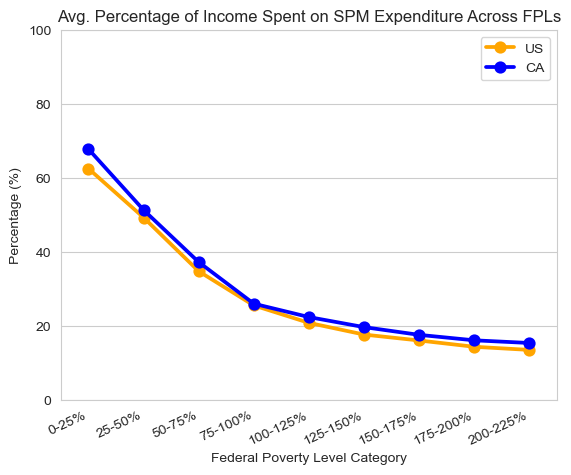

In [62]:
sns.pointplot(data = df_full,
             x = 'fpl_categ',
             y = 'food_to_inc',
             estimator = "mean", color = "orange", errorbar=None, label = "US")
sns.pointplot(data = df_cali,
             x = 'fpl_categ',
             y = 'food_to_inc',
             estimator = "mean", color = "blue", errorbar=None, label = "CA")
plt.xticks(rotation=25, ha='right')
plt.ylim(0,100)

plt.title("Avg. Percentage of Income Spent on SPM Expenditure Across FPLs")
plt.ylabel("Percentage (%)")
plt.xlabel("Federal Poverty Level Category")

Text(0.5, 0, 'Federal Poverty Levels')

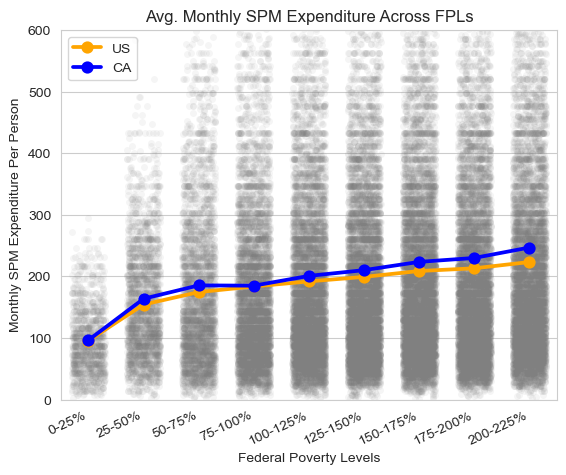

In [63]:
sns.pointplot(data = df_full,
             x = 'fpl_categ',
             y = 'MonthlyFoodSpendPerPerson',
             estimator = "mean",
             errorbar = ('se'), color = "orange", label = "US")
sns.pointplot(data = df_cali,
             x = 'fpl_categ',
             y = 'MonthlyFoodSpendPerPerson',
             estimator = "mean",
             errorbar = None, color = "blue", label = "CA")
sns.stripplot(data = df_full,
             x = 'fpl_categ',
             y = 'MonthlyFoodSpendPerPerson',
             alpha=0.08, color='grey', jitter=0.3, zorder=1)
plt.title("Avg. Monthly SPM Expenditure Across FPLs")
# plt.title("Nationwide Households below 400 fpl")
plt.ylim(0,600)
plt.xticks(rotation=25, ha='right')
plt.ylabel("Monthly SPM Expenditure Per Person")
plt.xlabel("Federal Poverty Levels")

### Heatmap

Part of EDA. Trying to see if anything in particular pops outs (nothing interesting). Line and bar charts are more effective at representing these variables in relation to each other

C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\1430889210.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = df_full.pivot_table(index='fpl_categ', columns='year', values='MonthlyFoodSpendPerPersonNoSnap', aggfunc='mean')


Text(0.5, 1.0, '[US] Average Food Expenditure Across FPLs Heatmap')

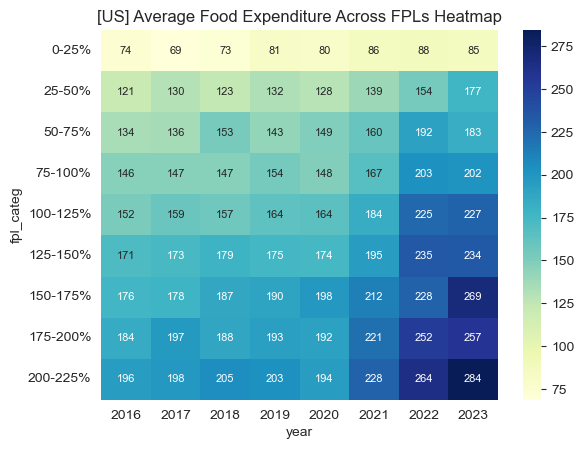

In [64]:
pivot_data = df_full.pivot_table(index='fpl_categ', columns='year', values='MonthlyFoodSpendPerPersonNoSnap', aggfunc='mean')

# Plot the heatmap
sns.heatmap(pivot_data, annot=True, annot_kws={"size": 8}, cmap='YlGnBu', fmt='.0f')
plt.title("[US] Average Food Expenditure Across FPLs Heatmap")

C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\2794835079.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = df_cali.pivot_table(index='fpl_categ', columns='year', values='MonthlyFoodSpendPerPersonNoSnap', aggfunc='mean')


Text(0.5, 1.0, '[CA] Average Food Expenditure Across FPLs Heatmap')

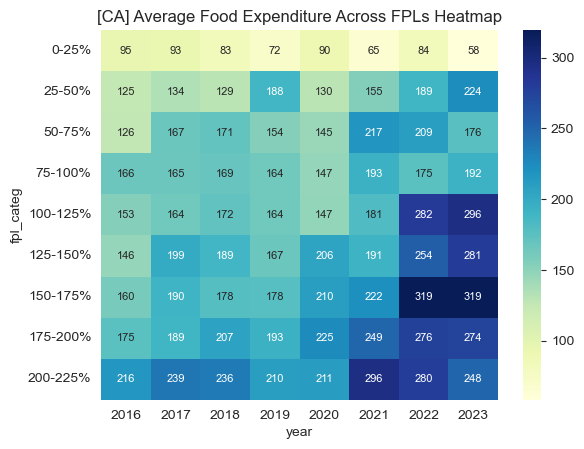

In [65]:
pivot_data = df_cali.pivot_table(index='fpl_categ', columns='year', values='MonthlyFoodSpendPerPersonNoSnap', aggfunc='mean')

# Plot the heatmap
sns.heatmap(pivot_data, annot=True, annot_kws={"size": 8}, cmap='YlGnBu', fmt='.0f')
plt.title("[CA] Average Food Expenditure Across FPLs Heatmap")

### Longidtudinal Viz

In [66]:
print(f"US rows: {df_full.shape}")
print(f"CA rows: {df_cali.shape}")
print(f"CA data is {round(df_cali.shape[0] / df_full.shape[0], 4)*100}% of US ")

US rows: (50807, 49)
CA rows: (5024, 49)
CA data is 9.89% of US 


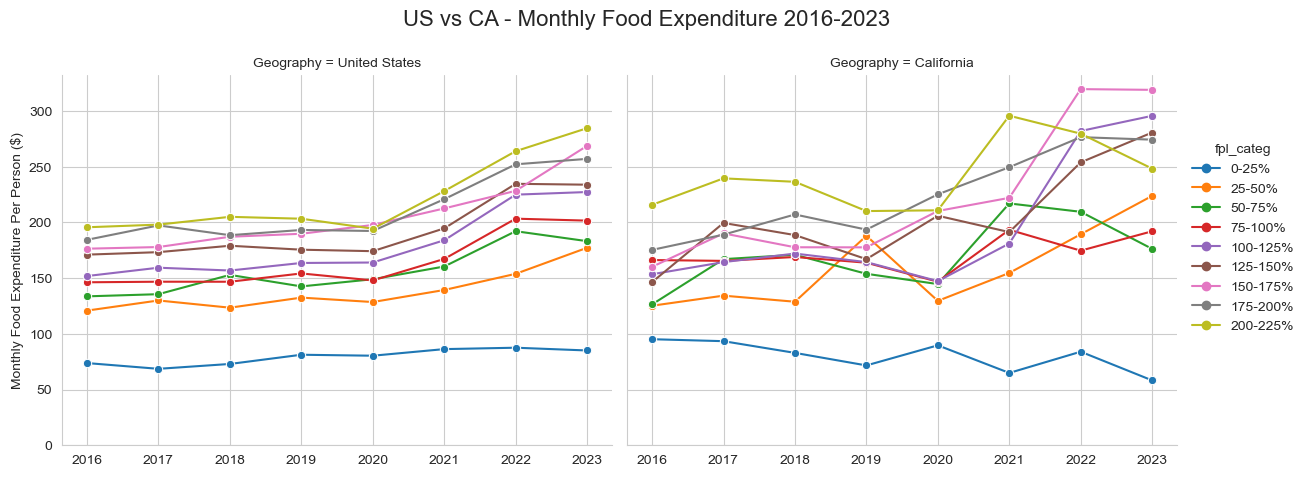

In [67]:
# 1. Create copies and add a 'Geography' column
df_cali_plot = df_cali.copy()
df_cali_plot['Geography'] = 'California'
# Standardize the Y-axis column name
df_cali_plot['Monthly SPM Expenditure Per Person'] = df_cali_plot['MonthlyFoodSpendPerPersonNoSnap']

df_full_plot = df_full.copy()
df_full_plot['Geography'] = 'United States'
# Standardize the Y-axis column name
df_full_plot['Monthly SPM Expenditure Per Person'] = df_full_plot['MonthlyFoodSpendPerPersonNoSnap']

# 2. Combine into one "Long-Form" dataframe
df_combined = pd.concat([df_full_plot, df_cali_plot])
df_combined['Year'] = df_combined['year']

# Plot side by side
g = sns.relplot(data=df_combined, 
                x='Year', 
                y='Monthly SPM Expenditure Per Person', 
                hue='fpl_categ', 
                kind='line', 
                col = "Geography",
                marker='o',
                height=5, 
                aspect=1.2, errorbar=None)

# Add the super title
g.fig.suptitle("US vs CA - Monthly Food Expenditure 2016-2023", fontsize=16)

# Adjust the 'top' of the subplots to make room
g.fig.subplots_adjust(top=0.85)
g.set_axis_labels("", "Monthly Food Expenditure Per Person ($)")
g.set(ylim=(0, None))

## Applying Weights

In [68]:
df_us_wt = pd.DataFrame()
row_temp = []

for wt in ['nation_weight']:
    for fpl in poverty_range_list:
        #calcualtes count of sampled households
        sample_count = len(df_full[df_full[fpl]==1])
        
        # calculates weigheted population % for a fpl
        numerator = (df_full[fpl] * df_full[wt]).sum() 
        denominator = df_full[wt].sum()
        wt_pct = round(numerator/denominator * 100, 2)

        # calculates weighted average monthly per person food expenditure for a fpl
        df_fpl_subset = df_full[df_full[fpl] == 1]
        weighted_avg = lambda x: np.average(x, weights=df_full.loc[x.index, wt])
        wt_avg = weighted_avg(df_fpl_subset['MonthlyFoodSpendPerPersonNoSnap'])

        # calculates se = std of the weighted mean
        my_obj = DescrStatsW(df_fpl_subset['MonthlyFoodSpendPerPersonNoSnap'], weights=df_fpl_subset[wt])
        wt_se = my_obj.std_mean

        # appending list of lists that will accumulate into a df
        row_temp.append([fpl, sample_count, wt_pct, wt_avg, wt_se, 'US'])

df_us_wt = pd.DataFrame(row_temp, columns=['fpl', 'sample_n', 'wt_pct', 'wt_avg', 'wt_se', 'wt_type'])
df_us_wt

,fpl,sample_n,wt_pct,wt_avg,wt_se,wt_type
0,0-25%,1116,2.41,76.222317,0.018676,US
1,25-50%,2169,4.49,131.736515,0.025006,US
2,50-75%,3182,6.53,151.646961,0.028016,US
3,75-100%,5384,10.70,158.777560,0.024465,US
4,100-125%,7034,13.69,172.590735,0.023104,US
5,125-150%,8084,15.71,188.198601,0.023317,US
6,150-175%,8226,15.95,200.231472,0.023965,US
7,175-200%,7944,15.57,205.641062,0.025150,US
8,200-225%,7696,15.02,215.584881,0.028568,US


In [69]:
df_ca_wt = pd.DataFrame()
row_temp = []

for wt in ['state_weight']:
    for fpl in poverty_range_list:

        #calcualtes count of sampled households
        sample_count = len(df_cali[df_cali[fpl]==1])
        
        # calculates weigheted population % for a fpl
        numerator = (df_cali[fpl] * df_cali[wt]).sum() 
        denominator = df_cali[wt].sum()
        wt_pct = round(numerator/denominator * 100, 2)

        # calculates weighted average monthly per person food expenditure for a fpl
        df_fpl_subset = df_cali[df_cali[fpl] == 1]
        weighted_avg = lambda x: np.average(x, weights=df_cali.loc[x.index, wt])
        wt_avg = weighted_avg(df_fpl_subset['MonthlyFoodSpendPerPersonNoSnap'])

        # calculates standard error = std / n
        my_obj = DescrStatsW(df_fpl_subset['MonthlyFoodSpendPerPersonNoSnap'], weights=df_fpl_subset[wt])
        wt_se = my_obj.std_mean

        # appending list of lists that will accumulate into a df
        row_temp.append([fpl, sample_count, wt_pct, wt_avg, wt_se, 'CA'])

df_ca_wt = pd.DataFrame(row_temp, columns=['fpl', 'sample_n', 'wt_pct', 'wt_avg', 'wt_se', 'wt_type'])
df_ca_wt

,fpl,sample_n,wt_pct,wt_avg,wt_se,wt_type
0,0-25%,90,1.65,83.773072,0.070333,CA
1,25-50%,221,4.25,149.969133,0.086724,CA
2,50-75%,357,7.20,160.648332,0.089558,CA
3,75-100%,626,12.50,165.595345,0.075233,CA
4,100-125%,713,13.21,180.408474,0.083056,CA
5,125-150%,757,15.18,193.041661,0.083873,CA
6,150-175%,758,14.87,210.633201,0.089965,CA
7,175-200%,775,15.78,209.192402,0.081424,CA
8,200-225%,731,15.51,231.793896,0.101305,CA


In [70]:
df_ca_us_wt = pd.concat([df_ca_wt, df_us_wt])
df_ca_us_wt

,fpl,sample_n,wt_pct,wt_avg,wt_se,wt_type
0,0-25%,90,1.65,83.773072,0.070333,CA
1,25-50%,221,4.25,149.969133,0.086724,CA
2,50-75%,357,7.20,160.648332,0.089558,CA
3,75-100%,626,12.50,165.595345,0.075233,CA
4,100-125%,713,13.21,180.408474,0.083056,CA
5,125-150%,757,15.18,193.041661,0.083873,CA
6,150-175%,758,14.87,210.633201,0.089965,CA
7,175-200%,775,15.78,209.192402,0.081424,CA
8,200-225%,731,15.51,231.793896,0.101305,CA
0,0-25%,1116,2.41,76.222317,0.018676,US


Text(36.09197916666666, 0.5, 'Weighted Avg $')

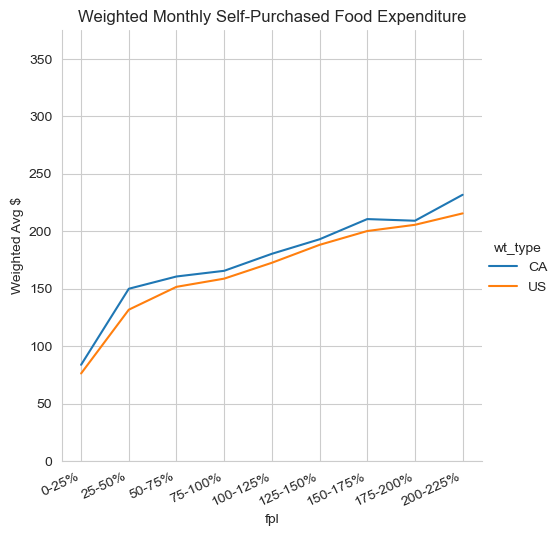

In [71]:
sns.relplot(data = df_ca_us_wt,
             x = 'fpl',
             y = 'wt_avg',
             hue = 'wt_type',
             kind = "line")
plt.ylim(0,375)
plt.xticks(rotation=25, ha='right')
plt.title("Weighted Monthly Self-Purchased Food Expenditure")
# plt.suptitle("CA weights applied to CA-only households\nUS weights applied to all households", fontsize = 10)

plt.ylabel("Weighted Avg $")

Text(35.01666666666666, 0.5, 'Weighted Percent %')

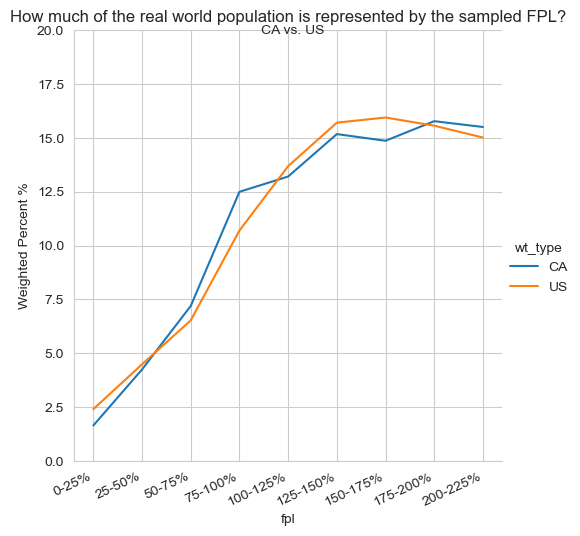

In [72]:
sns.relplot(data = df_ca_us_wt,
             x = 'fpl',
             y = 'wt_pct',
             hue = 'wt_type',
             kind = "line")
plt.ylim(0,20)
plt.xticks(rotation=25, ha='right')
plt.title("How much of the real world population is represented by the sampled FPL?")
plt.suptitle("CA vs. US", fontsize = 10)
plt.ylabel("Weighted Percent %")

Text(37.16729166666666, 0.5, 'Raw Count')

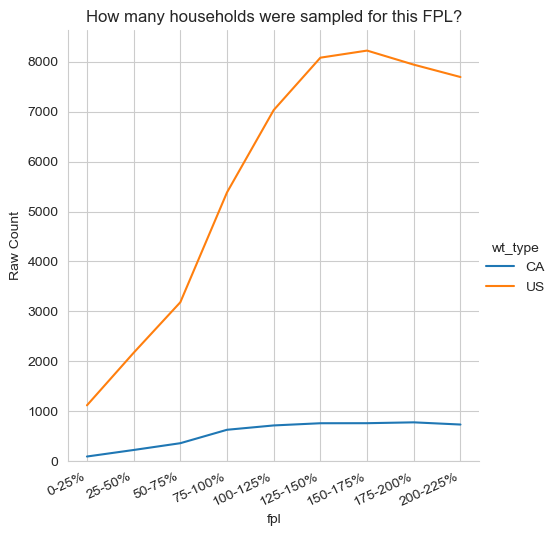

In [73]:
sns.relplot(data = df_ca_us_wt,
             x = 'fpl',
             y = 'sample_n',
             hue = 'wt_type',
             kind = "line")
plt.ylim(0,)
plt.xticks(rotation=25, ha='right')
plt.title("How many households were sampled for this FPL?")
plt.ylabel("Raw Count")

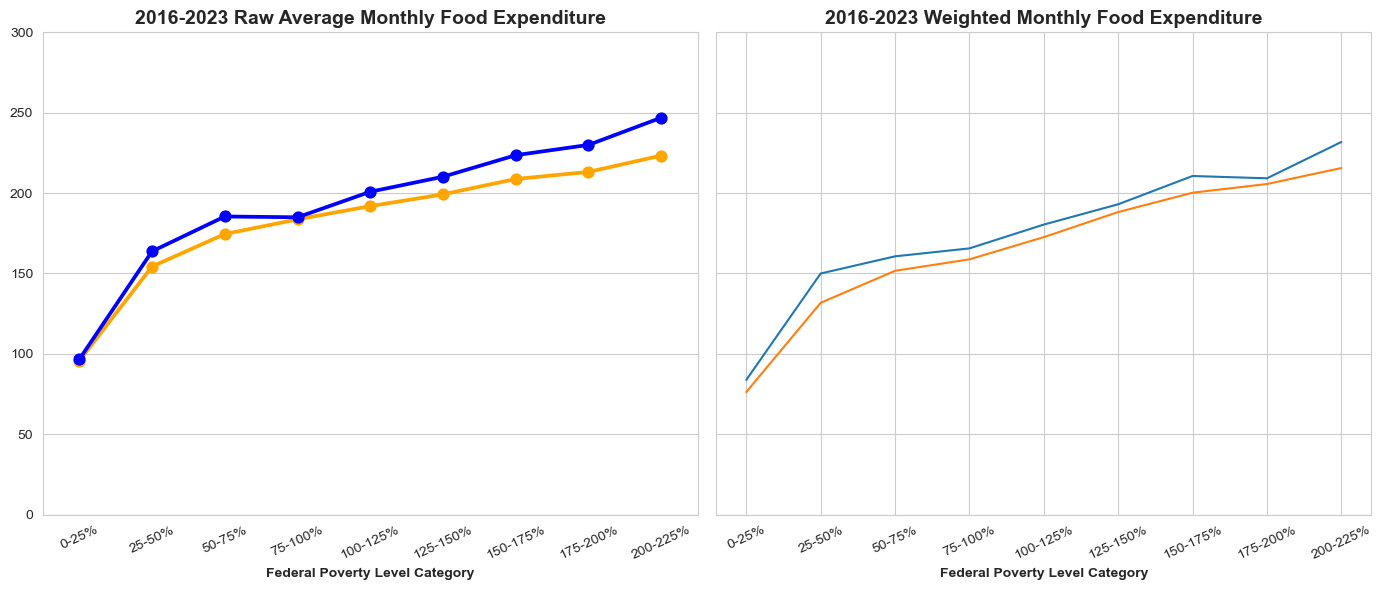

In [74]:

# 1. Set the global style
sns.set_style("whitegrid")

# 2. Initialize the subplot figure
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Define a shared "bold" configuration for reusable styling
bold_font = {'fontweight': 'bold'}

# --- LEFT PLOT: Weighted Averages ---
sns.lineplot(data=df_ca_us_wt,
             x='fpl',
             y='wt_avg',
             hue='wt_type',
             legend=False, 
             ax=ax1)

# Bold Titles and Labels
ax1.set_title("2016-2023 Weighted Monthly Food Expenditure", fontsize=14, **bold_font)
ax1.set_ylabel("Monthly Expenditure ($)", **bold_font)
ax1.set_xlabel("Federal Poverty Level Category", **bold_font)
ax1.tick_params(axis='both', labelsize=10) # Set tick label size
ax1.tick_params(axis='x', rotation=25)



# --- RIGHT PLOT: Raw Average Averages ---
sns.pointplot(data=df_full,
              x='fpl_categ',
              y='MonthlyFoodSpendPerPerson',
              estimator="mean",
              errorbar=None, 
              color="orange",
              ax=ax2)

sns.pointplot(data=df_cali,
              x='fpl_categ',
              y='MonthlyFoodSpendPerPerson',
              estimator="mean", 
              errorbar=None, 
              color="blue",
              ax=ax2)

# Bold Titles and Labels
ax2.set_title("2016-2023 Raw Average Monthly Food Expenditure", fontsize=14, **bold_font)
ax2.set_xlabel("Federal Poverty Level Category", **bold_font)
ax2.set_ylabel("", **bold_font) # Shared axis, keep empty but styled
ax2.tick_params(axis='x', rotation=25)


# 3. Final Polish
plt.ylim(0, 300) 
plt.tight_layout()
plt.show()

### df_groupby (WEIGHTED AVGs)

In [75]:
newdf_ca_us_wt = df_ca_us_wt[['fpl', 'wt_avg', 'wt_type']]
newdf_ca_us_wt['level_0'] = 'Weighted Average'
newdf_ca_us_wt.reset_index(inplace=True)
newdf_ca_us_wt[['fpl_categ', 'Average', 'geography']] = newdf_ca_us_wt[['fpl', 'wt_avg', 'wt_type']]

df_tableau = pd.concat([df_groupby, newdf_ca_us_wt, df_groupby_median])
df_tableau = df_tableau[['level_0', 'fpl_categ', 'Average', 'geography']]
# df_tableau[df_tableau['geography'] == 'US']

C:\Users\ariel\AppData\Local\Temp\ipykernel_32704\927979110.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  newdf_ca_us_wt['level_0'] = 'Weighted Average'


In [76]:
# export for tableau
df_tableau.to_csv("df_tableau_ariel.csv")

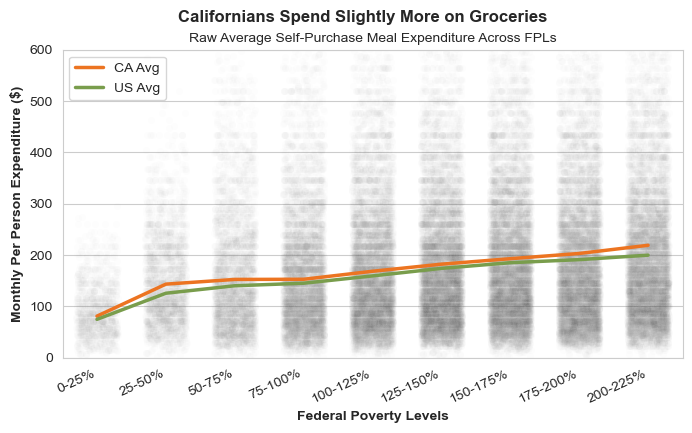

In [77]:
df_tableau = pd.read_csv("df_tableau_ariel.csv")
df_tableau['Method'] = df_tableau['level_0']
df_full['Geography'] = df_full['ca_dummy']

# Define a shared "bold" configuration for reusable styling
bold_font = {'fontweight': 'bold'}
line_style = {'linewidth': 2.5}

plt.figure(figsize=(8, 4))

sns.lineplot(data = df_tableau.query("geography == 'CA'"),
             x = 'fpl_categ', label = "CA Avg",
             y = 'Average', errorbar=None, color = "#ec7421", **line_style)

sns.lineplot(data = df_tableau.query("geography == 'US'"),
             x = 'fpl_categ', label = "US Avg",
             y = 'Average', errorbar=None, color = "#799d4c", **line_style)

sns.stripplot(data = df_full,
             x = 'fpl_categ',
             y = 'MonthlyFoodSpendPerPerson',
             alpha=0.015, color="grey", jitter=0.3, zorder=1)
plt.suptitle("Californians Spend Slightly More on Groceries", **bold_font)
plt.title("Raw Average Self-Purchase Meal Expenditure Across FPLs", fontsize = 10)
plt.ylim(0,600)
plt.xticks(rotation=25, ha='right')
plt.ylabel("Monthly Per Person Expenditure ($)", **bold_font)
plt.xlabel("Federal Poverty Levels", **bold_font)
plt.show()

### Comparing Central Tendency

In [78]:
# renaming variable
df_tableau['Method'] = df_tableau['level_0']

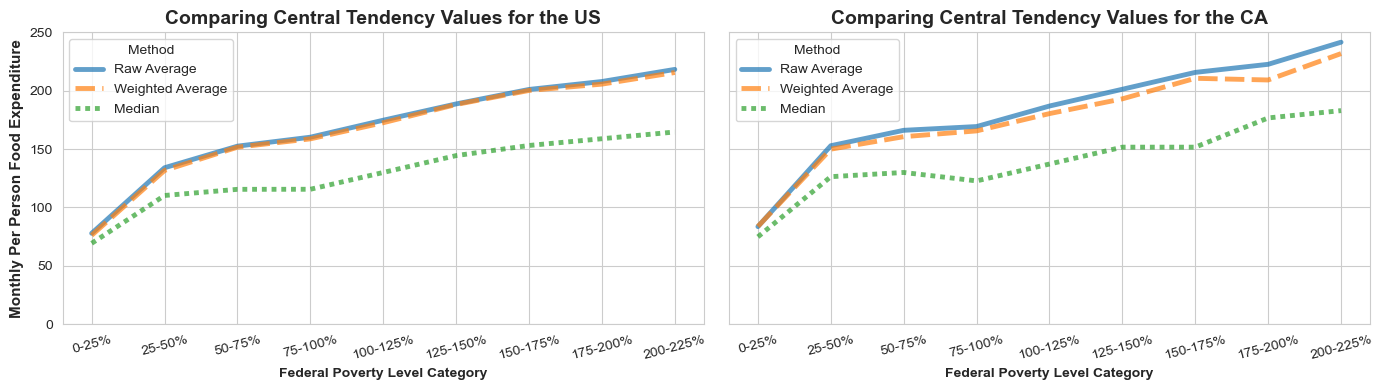

In [79]:
# 2. Initialize the subplot figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# Define a shared "bold" configuration for reusable styling
bold_font = {'fontweight': 'bold'}
line_style = {'linewidth': 3.5, 'alpha': 0.7}

# LEFT PLOT - US central tendency
sns.lineplot(data = df_tableau.query("geography=='US'"), 
            x='fpl_categ', 
            y = 'Average', 
            hue = 'Method',
            ax = ax1, style='Method', **line_style)
plt.ylim(0,300)
ax1.tick_params(axis='both', labelsize=10) # Set tick label size
ax1.tick_params(axis='x', rotation=15)
ax1.set_xlabel("Federal Poverty Level Category", **bold_font)
ax1.set_title("Comparing Central Tendency Values for the US", fontsize=14, **bold_font)
ax1.set_ylabel("Monthly Per Person Food Expenditure", fontsize=11, **bold_font) # Shared axis, keep empty but styled

# RIGHT PLOT - CA central tendency
sns.lineplot(data = df_tableau.query("geography=='CA'"), 
            x='fpl_categ', 
            y = 'Average', 
            hue = 'Method',
            ax = ax2, style='Method', **line_style)
ax2.set_xlabel("Federal Poverty Level Category", **bold_font)
ax2.set_title("Comparing Central Tendency Values for the CA", fontsize=14, **bold_font)
ax2.set_ylabel("", **bold_font) # Shared axis, keep empty but styled
ax2.set_ylabel("Monthly Per Person Food Expenditure", **bold_font) # Shared axis, keep empty but styled
ax2.tick_params(axis='x', rotation=15)

# 3. Final Polish
plt.ylim(0, 250) 
plt.tight_layout()
plt.show()

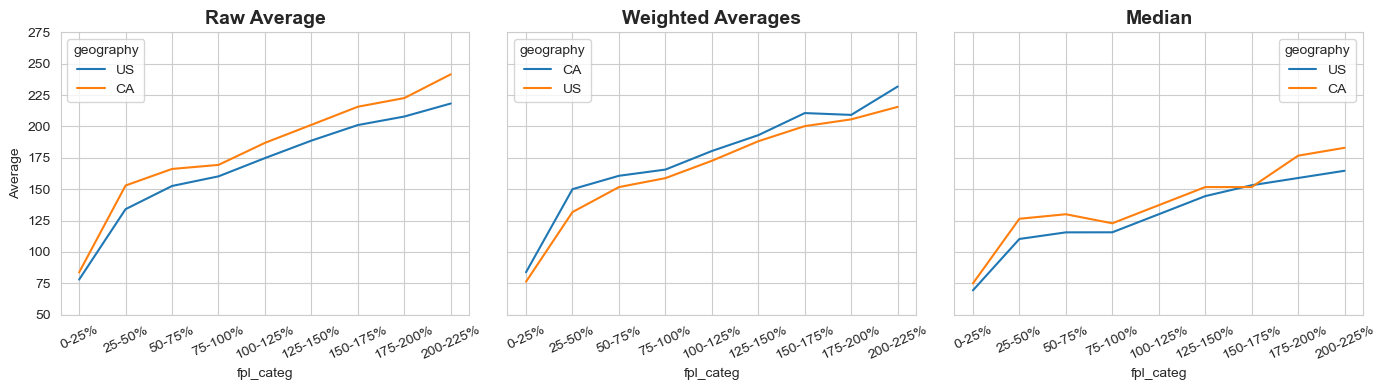

In [80]:
# 2. Initialize the subplot figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

# Define a shared "bold" configuration for reusable styling
bold_font = {'fontweight': 'bold'}

# LEFT PLOT - UNWEIGHTED
sns.lineplot(data = df_tableau.query("Method=='Raw Average'"),
             x='fpl_categ', 
            y = 'Average', 
            hue = 'geography',
            ax = ax1)
ax1.tick_params(axis='both', labelsize=10) # Set tick label size
ax1.tick_params(axis='x', rotation=25)
ax1.set_title("Raw Average", fontsize=14, **bold_font)

# MIDDLE PLOT - WEIGHTED
sns.lineplot(data = df_tableau.query("Method=='Weighted Average'"),
             x='fpl_categ', 
            y = 'Average', 
            hue = 'geography',
            ax = ax2)
ax2.tick_params(axis='both', labelsize=10) # Set tick label size
ax2.tick_params(axis='x', rotation=25)
ax2.set_title("Weighted Averages", fontsize=14, **bold_font)

# RIGHT PLOT - CA central tendency
sns.lineplot(data = df_tableau.query("Method=='Median'"),
             x='fpl_categ', 
            y = 'Average', 
            hue = 'geography',
            ax = ax3)
ax3.tick_params(axis='both', labelsize=10) # Set tick label size
ax3.tick_params(axis='x', rotation=25)
ax3.set_title("Median", fontsize=14, **bold_font)

# 3. Final Polish
plt.ylim(50, 275) 
plt.tight_layout()
plt.show()

## Linear Regression

In [81]:
my_formula = "MonthlyFoodSpendPerPersonNoSnap_ln ~  MonthlyIncomePerPerson_ln + MonthlyEBTPerPerson_log + quarter"
mod_ln = smf.ols(data = df_full, 
                 formula = my_formula).fit()

my_formula = "MonthlyFoodSpendPerPersonNoSnap_ln ~  MonthlyIncomePerPerson_ln + MonthlyEBTPerPerson_log + quarter"
mod_ln_ca = smf.ols(data = df_cali, 
                 formula = my_formula).fit()


In [82]:
mod_ln_ca.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    OLS Regression Results                                    
==============================================================================================
Dep. Variable:     MonthlyFoodSpendPerPersonNoSnap_ln   R-squared:                       0.205
Model:                                            OLS   Adj. R-squared:                  0.204
Method:                                 Least Squares   F-statistic:                     431.3
Date:                                Sun, 02 Aug 2026   Prob (F-statistic):          2.60e-249
Time:                                        14:35:47   Log-Likelihood:                -2045.5
No. Observations:                                5024   AIC:                             4099.
Df Residuals:                                    5020   BIC:                             4125.
Df Model:                                           3                                         
Covariance Type:                            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.7542      0.062     12.205      0.000       0.633       0.875
MonthlyIncomePerPerson_ln     0.1974      0.009     21.621      0.000       0.179       0.215
MonthlyEBTPerPerson_log      -0.2008      0.009    -23.163      0.000      -0.218      -0.184
quarter                       0.0053      0.001      9.397      0.000       0.004       0.006
==============================================================================
Omnibus:                      756.375   Durbin-Watson:                   1.524
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2354.189
Skew:                          -0.776   Prob(JB):                         0.00
Kurtosis:                       5.973   Cond. No.                         228.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [83]:
stargazer = Stargazer([mod_ln, mod_ln_ca])
HTML(stargazer.render_html())

In [84]:
my_formula = "MonthlyFoodSpendPerPersonNoSnap_ln ~  MonthlyIncomePerPerson_ln + MonthlyEBTPerPerson_log + EBT_dummy + quarter"
mod_ln_2 = smf.ols(data = df_full, 
                 formula = my_formula).fit()
my_formula = "MonthlyFoodSpendPerPersonNoSnap_ln ~  MonthlyIncomePerPerson_ln + MonthlyEBTPerPerson_log + EBT_dummy + quarter"
mod_ln_ca_2 = smf.ols(data = df_cali, 
                 formula = my_formula).fit()

stargazer = Stargazer([mod_ln_2, mod_ln_ca_2])
HTML(stargazer.render_html())

### Plotting Model Coefficients

In [85]:
# Build Model
X = df_full[['MonthlyIncomePerPerson_ln', 'MonthlyEBTPerPerson_log', 'quarter']]
y = df_full['MonthlyFoodSpendPerPersonNoSnap_ln']
X = sm.add_constant(X)
model = sm.OLS(y,X)
results = model.fit()

# Build Model
X = df_cali[['MonthlyIncomePerPerson_ln', 'MonthlyEBTPerPerson_log', 'quarter']]
y = df_cali['MonthlyFoodSpendPerPersonNoSnap_ln']
X = sm.add_constant(X)
model2 = sm.OLS(y,X)
results2 = model2.fit()

coef_df = pd.DataFrame(results.summary().tables[1].data)
    
# Add column names
coef_df.columns = coef_df.iloc[0]

# Drop the extra row with column labels
coef_df=coef_df.drop(0)

# Set index to variable names 
coef_df = coef_df.set_index(coef_df.columns[0])

# Change datatype from object to float
coef_df = coef_df.astype(float)

# Get errors; (coef - lower bound of conf interval)
errors = coef_df['coef'] - coef_df['[0.025']

# Append errors column to dataframe
coef_df['errors'] = errors

# Drop the constant for plotting
# coef_df = coef_df.drop(['const'])

# Sort values by coef ascending
coef_df = coef_df.sort_values(by=['coef'])

coef_df['Geography'] = 'US'
coef_df


coef_df_2 = pd.DataFrame(results.summary().tables[1].data)
    
# Add column names
coef_df_2.columns = coef_df_2.iloc[0]

# Drop the extra row with column labels
coef_df_2=coef_df_2.drop(0)

# Set index to variable names 
coef_df_2 = coef_df_2.set_index(coef_df_2.columns[0])

# Change datatype from object to float
coef_df_2 = coef_df_2.astype(float)

# Get errors; (coef - lower bound of conf interval)
errors = coef_df_2['coef'] - coef_df_2['[0.025']

# Append errors column to dataframe
coef_df_2['errors'] = errors

# Sort values by coef ascending
coef_df_2 = coef_df_2.sort_values(by=['coef'])

coef_df_2['Geography'] = 'CA'

coef_df_2

coef_df_3 = pd.concat([coef_df, coef_df_2])
coef_df_3

,coef,std err,t,P>|t|,[0.025,0.975],errors,Geography
,,,,,,,,
MonthlyEBTPerPerson_log,-0.1919,0.003,-76.002,0.0,-0.197,-0.187,0.0051,US
quarter,0.0042,0.000,24.205,0.0,0.004,0.005,0.0002,US
MonthlyIncomePerPerson_ln,0.1850,0.003,66.617,0.0,0.180,0.190,0.0050,US
const,0.8250,0.019,43.207,0.0,0.788,0.862,0.0370,US
MonthlyEBTPerPerson_log,-0.1919,0.003,-76.002,0.0,-0.197,-0.187,0.0051,CA
quarter,0.0042,0.000,24.205,0.0,0.004,0.005,0.0002,CA
MonthlyIncomePerPerson_ln,0.1850,0.003,66.617,0.0,0.180,0.190,0.0050,CA
const,0.8250,0.019,43.207,0.0,0.788,0.862,0.0370,CA


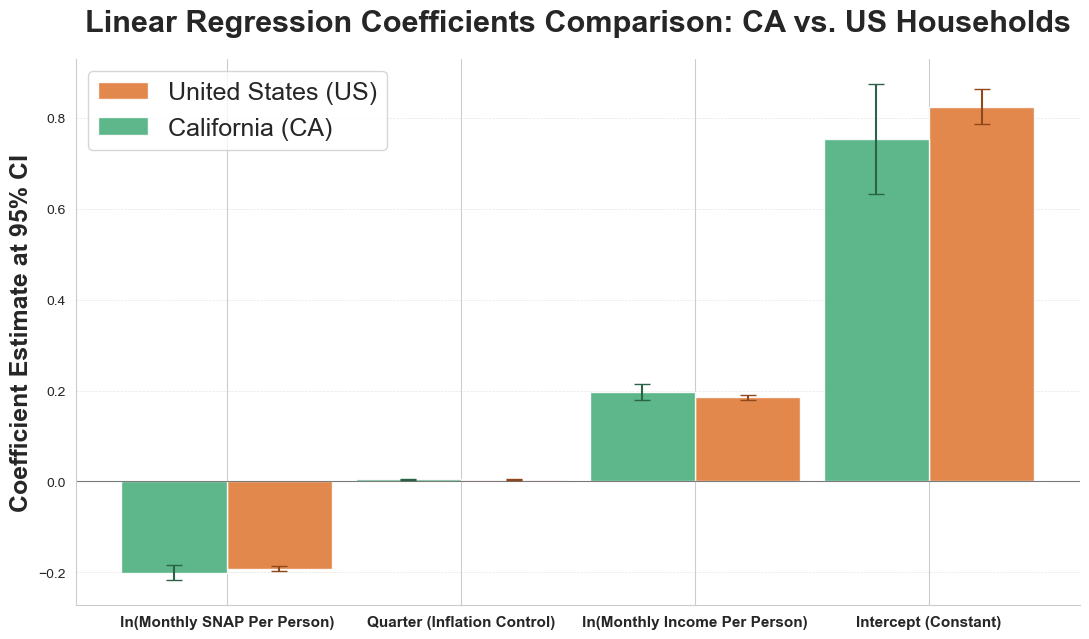

In [86]:
# --- STEP 1: Extract Model Data Safely using Statsmodels Built-ins ---
def extract_model_metrics(results_obj, geography_label):
    coef = results_obj.params
    conf = results_obj.conf_int(alpha=0.05)  # 95% CI

    df = pd.DataFrame(
        {
            "coef": coef,
            "ci_lower": conf[0],
            "ci_upper": conf[1],
            "Geography": geography_label,
        }
    )
    df["err_lower"] = df["coef"] - df["ci_lower"]
    df["err_upper"] = df["ci_upper"] - df["coef"]
    return df


# Extract and combine model objects
df_us_metrics = extract_model_metrics(results, "US")
df_ca_metrics = extract_model_metrics(results2, "CA")
coef_df_3 = pd.concat([df_ca_metrics, df_us_metrics]).reset_index()
coef_df_3.rename(columns={"index": "Raw_Feature"}, inplace=True)


# --- THE CLEANUP FIX: Explicit Variable Mapping Dictionary ---
# This matches your exact statsmodels variable strings to elegant chart labels
name_mapping = {
    "const": "Intercept (Constant)",
    "MonthlyIncomePerPerson_ln": "ln(Monthly Income Per Person)",
    "MonthlyEBTPerPerson_log": "ln(Monthly SNAP Per Person)",
    "quarter": "Quarter (Inflation Control)"
}

# Apply the mapping directly to the long-form dataframe
coef_df_3["Features"] = coef_df_3["Raw_Feature"].map(name_mapping)

# In case a variable isn't in the dictionary, fall back to the raw name safely
coef_df_3["Features"] = coef_df_3["Features"].fillna(coef_df_3["Raw_Feature"])


# --- STEP 2: Pivot Data Using the Brand New 'Features' Column ---
# Now your labels carry over into the pivot index automatically!
plot_df = coef_df_3.pivot(index="Features", columns="Geography", values="coef")
err_lower_df = coef_df_3.pivot(index="Features", columns="Geography", values="err_lower")
err_upper_df = coef_df_3.pivot(index="Features", columns="Geography", values="err_upper")

# Sort by US values so bars stack progressively on the plot
plot_df = plot_df.sort_values(by="US", ascending=True)
err_lower_df = err_lower_df.reindex(plot_df.index)
err_upper_df = err_upper_df.reindex(plot_df.index)

# Re-stack for Matplotlib's asymmetric error tracking
errors_ca = np.vstack([err_lower_df["CA"], err_upper_df["CA"]])
errors_us = np.vstack([err_lower_df["US"], err_upper_df["US"]])


# --- STEP 3: Plot Grouped Bar Chart with CI Whiskers ---
fig, ax = plt.subplots(figsize=(11, 6.5)) # Slightly bumped width for cleaner text margins

x_indexes = np.arange(len(plot_df.index))
bar_width = 0.45

# Plot US (Right Bar)
bars_us = ax.bar(
    x_indexes + bar_width / 2,
    plot_df["US"],
    width=bar_width,
    yerr=errors_us,
    label="United States (US)",
    color="#E07B3A",
    ecolor="#8F481B",
    capsize=6,
    alpha=0.9,
)

# Plot CA (Left Bar)
bars_ca = ax.bar(
    x_indexes - bar_width / 2,
    plot_df["CA"],
    width=bar_width,
    yerr=errors_ca,
    label="California (CA)",
    color="#4BAF7D",
    ecolor="#2A6347",
    capsize=6,
    alpha=0.9,
)

# Plot styling adjustments
ax.axhline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.5)
ax.set_xticks(x_indexes)

# Clean labels directly populate plot_df.index now!
ax.set_xticklabels(plot_df.index, fontsize=11, fontweight="bold")

ax.set_ylabel("Coefficient Estimate at 95% CI", fontweight="bold", fontsize=18)
ax.set_title(
    "Linear Regression Coefficients Comparison: CA vs. US Households",
    fontsize=22,
    fontweight="bold",
    pad=20,
)

ax.legend(fontsize=18, framealpha=0.8, loc="best")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

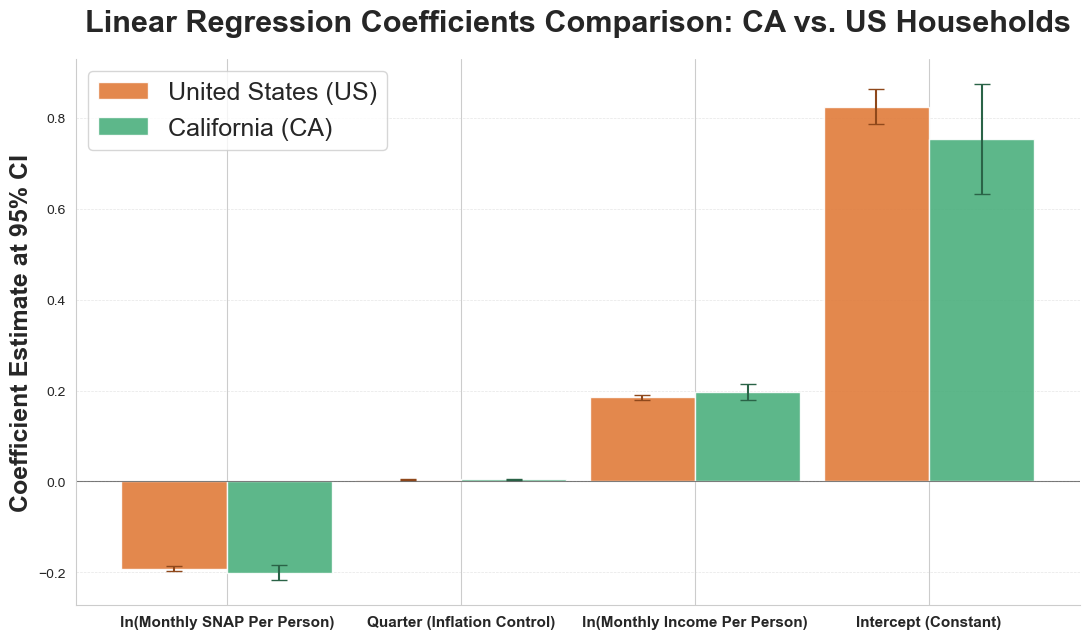

In [87]:
# --- STEP 3: Plot Grouped Bar Chart with CI Whiskers ---
fig, ax = plt.subplots(figsize=(11, 6.5)) 

x_indexes = np.arange(len(plot_df.index))
bar_width = 0.45

# 1. Plot US (Now shifted to the LEFT by using: - bar_width / 2)
bars_us = ax.bar(
    x_indexes - bar_width / 2,   # <--- CHANGED TO MINUS
    plot_df["US"],
    width=bar_width,
    yerr=errors_us,
    label="United States (US)",
    color="#E07B3A",
    ecolor="#8F481B",
    capsize=6,
    alpha=0.9,
)

# 2. Plot CA (Now shifted to the RIGHT by using: + bar_width / 2)
bars_ca = ax.bar(
    x_indexes + bar_width / 2,   # <--- CHANGED TO PLUS
    plot_df["CA"],
    width=bar_width,
    yerr=errors_ca,
    label="California (CA)",
    color="#4BAF7D",
    ecolor="#2A6347",
    capsize=6,
    alpha=0.9,
)

# --- Rest of your plot styling remains exactly the same ---
ax.axhline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.5)
ax.set_xticks(x_indexes)

# Clean labels directly populate plot_df.index now!
ax.set_xticklabels(
    plot_df.index, 
    rotation_mode='anchor', 
    fontsize=11, 
    fontweight="bold"
)

ax.set_ylabel("Coefficient Estimate at 95% CI", fontweight="bold", fontsize=18)
ax.set_title(
    "Linear Regression Coefficients Comparison: CA vs. US Households",
    fontsize=22,
    fontweight="bold",
    pad=20,
)

ax.legend(fontsize=18, framealpha=0.8, loc="best")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

### Plotting Bivariate Regression Chart


CA model:
   Intercept : $59.85
   Slope     : 0.0109
   R²        : 0.141

US model:
   Intercept : $66.27
   Slope     : 0.0088
   R²        : 0.115


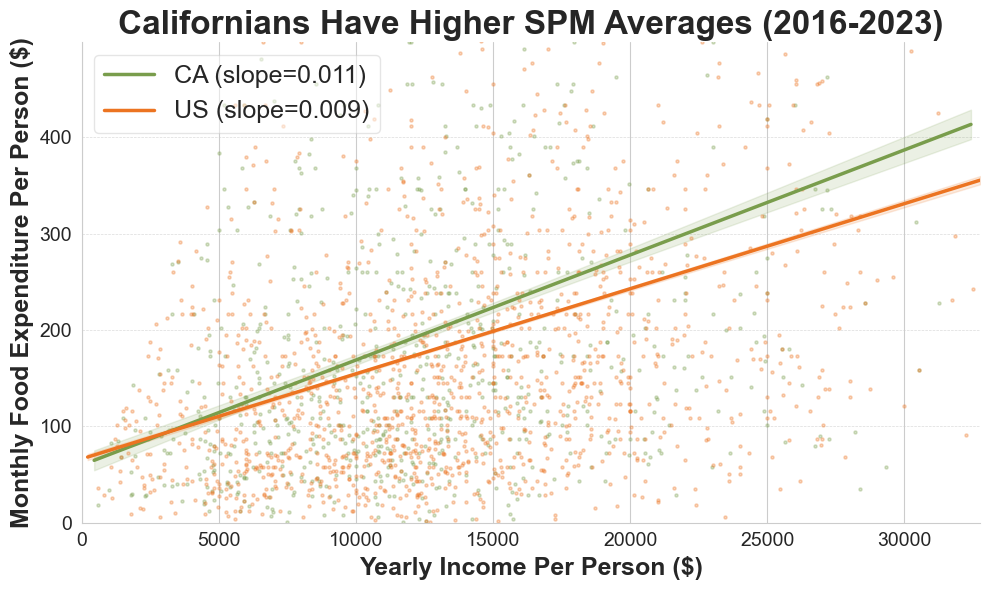

In [88]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

fig, ax = plt.subplots(figsize=(10, 6))

groups = [
    ('CA',  df_cali,  "#799d4c"),
    ('US',  df_full,  "#ec7421"),
]

# Track the absolute maximum income across both groups
max_x_limit = 0

for label, df_grp, color in groups:

    # Bivariate model just for plotting
    mod_plot = smf.ols(
        data=df_grp,
        formula="MonthlyFoodSpendPerPersonNoSnap ~ IncomePerPerson"
    ).fit()

    # --- THE FIX: Use max() instead of the 99th percentile ---
    local_max = df_grp['IncomePerPerson'].max()
    max_x_limit = max(max_x_limit, local_max)

    # Generate range stretching all the way to the maximum value
    income_range = np.linspace(
        df_grp['IncomePerPerson'].min(), # Captures the true absolute bottom
        local_max,                       # Captures the true absolute top (~30k)
        300
    )

    pred_df   = pd.DataFrame({'IncomePerPerson': income_range})
    pred      = mod_plot.get_prediction(pred_df)
    pred_summ = pred.summary_frame(alpha=0.05)

    # Scatter — thin out US points heavily so CA is visible
    n_scatter = 1500 if label == 'US' else 800
    df_sample = df_grp.sample(n=n_scatter, random_state=42, replace=False)
    
    ax.scatter(
        df_sample['IncomePerPerson'],
        df_sample['MonthlyFoodSpendPerPersonNoSnap'],
        alpha=0.3, s=5, color=color
    )

    # Fitted line
    ax.plot(
        income_range, pred_summ['mean'],
        color=color, linewidth=2.5, label=f'{label} (slope={mod_plot.params.iloc[1]:.3f})'
    )

    # 95% CI band on the mean
    ax.fill_between(
        income_range,
        pred_summ['mean_ci_lower'],
        pred_summ['mean_ci_upper'],
        color=color, alpha=0.15
    )

    # Print slope + intercept for reference
    print(f"\n{label} model:")
    print(f"   Intercept : ${mod_plot.params.iloc[0]:.2f}")
    print(f"   Slope     : {mod_plot.params.iloc[1]:.4f}")
    print(f"   R²        : {mod_plot.rsquared:.3f}")

# Set limits dynamically to the absolute max value found (~30k)
ax.set_xlim(0, max_x_limit)
ax.set_ylim(0, df_full['MonthlyFoodSpendPerPersonNoSnap'].quantile(0.95))

ax.set_xlabel('Yearly Income Per Person ($)', fontweight="bold", fontsize=18)
ax.set_ylabel('Monthly Food Expenditure Per Person ($)', fontweight="bold", fontsize=18)
ax.set_title( 'Californians Have Higher SPM Averages (2016-2023)',
    fontsize=24, fontweight='bold'
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

ax.legend(fontsize=18, framealpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


CA model:
   Intercept : $59.85
   Slope     : 0.0109  (every $1 income → $0.0109 food spend)
   R²        : 0.141

US model:
   Intercept : $66.27
   Slope     : 0.0088  (every $1 income → $0.0088 food spend)
   R²        : 0.115


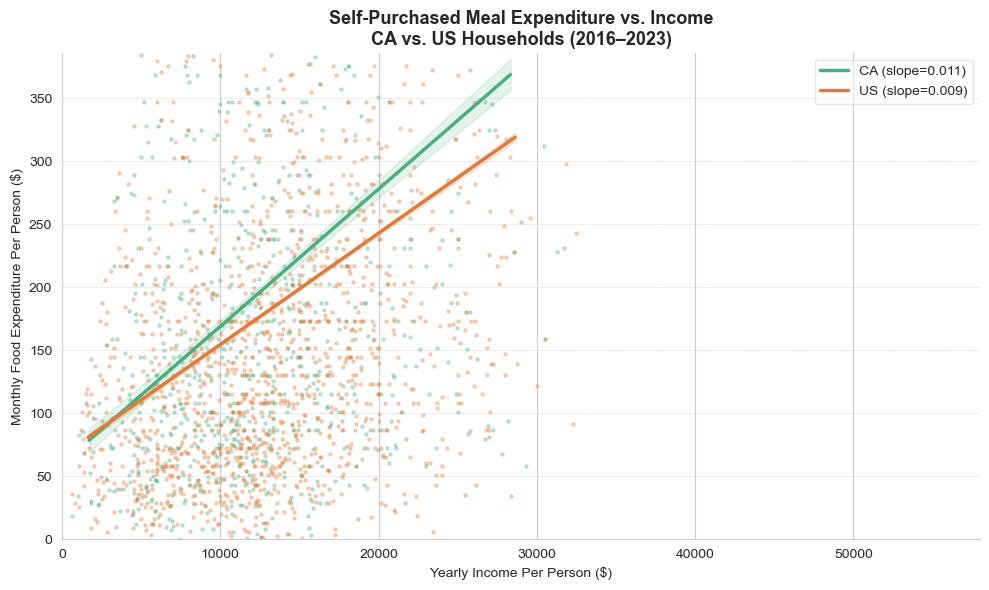

In [89]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

fig, ax = plt.subplots(figsize=(10, 6))

groups = [
    ('CA',  df_cali,  '#4BAF7D'),
    ('US',  df_full,  '#E07B3A'),
]

for label, df_grp, color in groups:

    # Bivariate model just for plotting
    mod_plot = smf.ols(
        data=df_grp,
        formula="MonthlyFoodSpendPerPersonNoSnap ~ IncomePerPerson"
    ).fit()

    # Income range clipped to avoid outlier distortion
    income_range = np.linspace(
        df_grp['IncomePerPerson'].quantile(0.01),
        df_grp['IncomePerPerson'].quantile(0.99),
        300
    )

    pred_df   = pd.DataFrame({'IncomePerPerson': income_range})
    pred      = mod_plot.get_prediction(pred_df)
    pred_summ = pred.summary_frame(alpha=0.05)

    # --- FIX #1: Safe Scatter Sampling ---
    # Sample the dataframe rows directly instead of indexing into the old indices
    n_scatter = 1500 if label == 'US' else 800
    df_sample = df_grp.sample(n=n_scatter, random_state=42, replace=False)
    
    ax.scatter(
        df_sample['IncomePerPerson'],
        df_sample['MonthlyFoodSpendPerPersonNoSnap'],
        alpha=0.3, s=5, color=color
    )

    # Fitted line
    ax.plot(
        income_range, pred_summ['mean'],
        color=color, linewidth=2.5, label=f'{label} (slope={mod_plot.params.iloc[1]:.3f})'
    )

    # 95% CI band on the mean
    ax.fill_between(
        income_range,
        pred_summ['mean_ci_lower'],
        pred_summ['mean_ci_upper'],
        color=color, alpha=0.15
    )

    # Print slope + intercept for reference
    # Note: Using .iloc instead of position indices to prevent future statsmodels warnings
    print(f"\n{label} model:")
    print(f"   Intercept : ${mod_plot.params.iloc[0]:.2f}")
    print(f"   Slope     : {mod_plot.params.iloc[1]:.4f}  (every $1 income → ${mod_plot.params.iloc[1]:.4f} food spend)")
    print(f"   R²        : {mod_plot.rsquared:.3f}")

# --- FIX #2: Clean Axis Adjustments ---
# Set the limits on the specific axis object (ax) before final show
ax.set_xlim(0, 58000) # Replaces the duplicate plt.xlim at the bottom
ax.set_ylim(0, df_full['MonthlyFoodSpendPerPersonNoSnap'].quantile(0.9))

ax.set_xlabel('Yearly Income Per Person ($)')
ax.set_ylabel('Monthly Food Expenditure Per Person ($)')
ax.set_title(
    'Self-Purchased Meal Expenditure vs. Income\nCA vs. US Households (2016–2023)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10, framealpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()

# --- FIX #3: Save Sequence ---
# Always save before showing, otherwise plt.show() flushes the buffer and leaves the image blank
plt.show()


CA model:
  Intercept : $59.85
  Slope     : 0.0109
  R²        : 0.141
  N         : 5,024

US model:
  Intercept : $66.27
  Slope     : 0.0088
  R²        : 0.115
  N         : 50,807


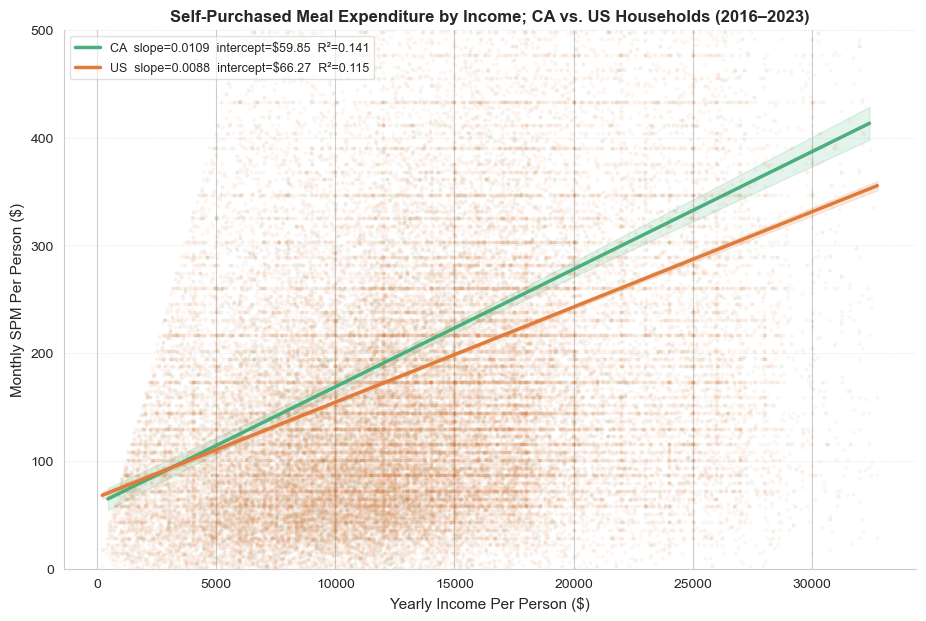

<Figure size 800x400 with 0 Axes>

In [90]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

fig, ax = plt.subplots(figsize=(11, 7))

groups = [
    ('CA', df_cali, '#4BAF7D'),
    ('US', df_full, '#E07B3A'),
]

for label, df_grp, color in groups:

    # Fit on full data, no clipping
    mod_plot = smf.ols(
        data=df_grp,
        formula="MonthlyFoodSpendPerPersonNoSnap ~ IncomePerPerson"
    ).fit()

    # Income range spans full observed range
    income_range = np.linspace(
        df_grp['IncomePerPerson'].min(),
        df_grp['IncomePerPerson'].max(),
        300
    )

    pred_df   = pd.DataFrame({'IncomePerPerson': income_range})
    pred      = mod_plot.get_prediction(pred_df)
    pred_summ = pred.summary_frame(alpha=0.05)

    # Plot ALL points — no sampling, full dataset
    ax.scatter(
        df_grp['IncomePerPerson'],
        df_grp['MonthlyFoodSpendPerPersonNoSnap'],
        alpha=0.04,      # very low alpha so dense regions show as dark clouds
        s=4,
        color=color,
        rasterized=True  # rasterize points for faster rendering with large N
    )

    # Fitted line
    ax.plot(
        income_range, pred_summ['mean'],
        color=color, linewidth=2.5,
        label=f'{label}  slope={mod_plot.params.iloc[1]:.4f}  intercept=${mod_plot.params.iloc[0]:.2f}  R²={mod_plot.rsquared:.3f}'
    )

    # 95% CI band
    ax.fill_between(
        income_range,
        pred_summ['mean_ci_lower'],
        pred_summ['mean_ci_upper'],
        color=color, alpha=0.15
    )

    print(f"\n{label} model:")
    print(f"  Intercept : ${mod_plot.params.iloc[0]:.2f}")
    print(f"  Slope     : {mod_plot.params.iloc[1]:.4f}")
    print(f"  R²        : {mod_plot.rsquared:.3f}")
    print(f"  N         : {len(df_grp):,}")

# No xlim/ylim — let matplotlib fit to the full data range naturally
ax.set_xlabel('Yearly Income Per Person ($)', fontsize=11)
ax.set_ylabel('Monthly SPM Per Person ($)', fontsize=11)
ax.set_title(
    'Self-Purchased Meal Expenditure by Income; CA vs. US Households (2016–2023)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9, framealpha=0.6)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.4)

plt.ylim(0,500)
plt.figure(figsize=(8, 4))
plt.tight_layout()
plt.show()